## 1 - Data Analysis

El objetivo principal es extraer y analizar los datos de la base de datos ***MIMIC-IV***
El primer paso es analizar de que tipo de datos disponemos, de primeras se puede observar que el formato de los archivos es `csv.gz`, el formato `gz` indica que es un archivo comprimido, y previamente tiene el formato `csv`, por lo tanto se puede llegar a suponer que es un archivo csv comprimido. La librería pandas ayudará a leer los archivos csv comprimidos directamente sin descompresión manual.

Lo principal es importar las librerías que serán necesarias para analizar y procesar estos datos

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

In [2]:
# ── CONFIGURACIÓN GLOBAL ────────────────────────────────────────────────────
BASE_DATA_DIR  = '../data'            # Directorio raíz del dataset MIMIC-IV
OUTPUT_DIR     = '../data/processed'  # Directorio de salida para artefactos

HOURS_BEFORE   = 48   # Ventana temporal previa al ingreso UCI (horas)
MIN_STAY_HOURS = 6    # Cobertura mínima de horas por estancia

Path(OUTPUT_DIR).mkdir(parents=True, exist_ok=True)
# ────────────────────────────────────────────────────────────────────────────

Con las librerías requeridas cargadas ya se pueden importar y empezar a usar los datos, aunque antes hay que entender cómo están estructurados y qué relación hay entre diferentes archivos `csv`.

Según la documentación de **MIMIC-IV** tenemos dos directorios principales:

- **hosp**: Contiene **546,028** registros únicos de hospitalizaciones para **223,452** individuos únicos. Estos datos se dividen en cuatro categorías principales:
    - **Información Básica y Logística**: Incluye los datos personales de los pacientes (edad, género, etc), y registra cuando entra y sale un paciente de una unidad en concreto.
    - **Datos Clínicos y de Laboratorio**: Contiene eventos registrados en un laboratorio, como por ejemplo resultados de análisis de sangre, orina, etc.
    - **Medicamentos**: Contiene las recetas prescritas por los médicos, también incluye un registro de cuando y como se ha administrado el medicamiento.
    - **Facturación y Diagnósticos**: Incluye los datos que indican los códigos de los diagnósticos y procedimientos realizados.

- **icu**: Contiene **94,458** registros de estancias de pacientes en la UCI. Estos datos se estructuran de forma que hay una tabla "estancias" central que se conecta con otras tablas de eventos, estas tablas registran todos los sucesos de un paciente minuto a minuto.

Con este conocimiento solo queda conocer los campos que enlazan las diferentes tablas, los campos más importantes son:

- `subject_id`: Identificador único del paciente
- `hadm_id`: Identificador único de admisión hospitalaria (un paciente puede tener más de una admisión)
- `stay_id`: Identificador único de estancia en la UCI (una admisión puede tener varias estancias)

In [3]:
ID_SUBJECT = 'subject_id'
ID_ADMISION = 'hadm_id'
ID_STAY = 'stay_id'

El primer paso se tratará de analizar los diagnósticos del dataset usando la variable `icd_code`, esta variable nos indica el código ICD del diagnóstico, este código usa un sistema estandarizado para codificar enfermedades, signos o síntomas, actualmente existen dos principales revisiones: **ICD-9** y **ICD-10**. Estas dos revisiones varían sobre todo en la cantidad de códigos y estructura, el objetivo es usar estos códigos para identificar en el dataset los diagnosis que contengan casos de sepsis, o algún síntoma o enfermedad que nos ayude a indicar la sepsis, se usará la variable `icd_version` para identificar la versión en los datos.


### ICD-9

| Código(s) | Descripción |
|-----------|-------------|
| **995.91** | Sepsis (SIRS de origen infeccioso) |
| **995.92** | Sepsis grave |
| **785.52** | Choque séptico |
| **038.0–038.9** | Septicemia (038.11 Staph aureus, 038.42 E. coli, 038.9 no especificada) |
| **771.81** | Sepsis neonatal |

### ICD-10

| Código(s) | Descripción |
|-----------|-------------|
| **A41.9** | Sepsis, organismo no especificado (el más común en registros) |
| **A40.0, A40.1, A40.3, A40.8, A40.9** | Sepsis por diferentes grupos de Estreptococos |
| **A41.01** | Sepsis por *Staphylococcus aureus* sensible a meticilina (MSSA) |
| **A41.02** | Sepsis por *Staphylococcus aureus* resistente a meticilina (MRSA) |
| **A41.51** | Sepsis por *Escherichia coli* |
| **A41.52** | Sepsis por *Pseudomonas* |
| **A41.81** | Sepsis por *Enterococcus* |
| **A41.89** | Sepsis por otros organismos especificados (incluye sepsis viral) |
| **A02.1** | Sepsis por *Salmonella* |
| **B37.7** | Sepsis candidiásica (fúngica) |
| **R65.20** | Sepsis grave sin choque séptico |
| **R65.21** | Sepsis grave con choque séptico |
| **P36.0–P36.9** | Sepsis bacteriana neonatal |
| **O85** | Sepsis puerperal (postparto) |
| **O75.3** | Sepsis durante el trabajo de parto |
| **T81.44** | Sepsis tras procedimiento quirúrgico |

In [4]:
diagnoses = pd.read_csv(f'{BASE_DATA_DIR}/hosp/diagnoses_icd.csv.gz')
print(diagnoses.shape)
print(diagnoses.dtypes)
print(diagnoses.head())

(6364488, 5)
subject_id     int64
hadm_id        int64
seq_num        int64
icd_code         str
icd_version    int64
dtype: object
   subject_id   hadm_id  seq_num icd_code  icd_version
0    10000032  22595853        1     5723            9
1    10000032  22595853        2    78959            9
2    10000032  22595853        3     5715            9
3    10000032  22595853        4    07070            9
4    10000032  22595853        5      496            9


In [5]:
ICD_CODE = 'icd_code' # Identificador del codigo de ICD 
ICD_VERSION = 'icd_version' # Identificador de la version de ICD

# ---------------------------------- ICD 9 ----------------------------------

# Definimos los codigos especificos de ICD9
SEPSIS_ICD9_EXPLICIT = {
    '99591',  # Sepsis
    '99592',  # Sepsis grave
    '78552',  # Choque séptico
    '77181',  # Sepsis neonatal
}

# Filtramos por version
icd9_df = diagnoses[diagnoses[ICD_VERSION] == 9].copy()

# Incluimos los diagnosis con codigo que empieza por 038 (Septicemia)
icd9_mask = (
    icd9_df[ICD_CODE].isin(SEPSIS_ICD9_EXPLICIT) |
    icd9_df[ICD_CODE].str.startswith('038')
)

# Evitamos registros duplicados identificandolos por admision
sepsis_icd9_hadm = icd9_df[icd9_mask][ID_ADMISION].unique()

# ---------------------------------- ICD 10 ----------------------------------

# Prefijos A40.x y A41.x, se capturan todos los subtipos
ICD10_SEPSIS_PREFIXES = ('A40', 'A41')

# Códigos adicionales fuera de A40/A41
ICD10_SEPSIS_EXTRA = {
    'A021',   # Salmonella sepsis
    'B377',   # Candida sepsis (fúngica)
    'R6520',  # Sepsis grave sin choque séptico
    'R6521',  # Sepsis grave con choque séptico
    'O85',    # Sepsis puerperal
    'O753',   # Sepsis durante el trabajo de parto
    'T8144',  # Sepsis postquirúrgica
}

# Prefijos de sepsis neonatal P36.x
ICD10_NEONATAL_PREFIX = ('P36',)

# Filtramos por version y incluimos todos los codigos
icd10_mask = (
    (diagnoses[ICD_VERSION] == 10) &
    (
        diagnoses[ICD_CODE].str.startswith(ICD10_SEPSIS_PREFIXES) |
        diagnoses[ICD_CODE].str.startswith(ICD10_NEONATAL_PREFIX) |
        diagnoses[ICD_CODE].isin(ICD10_SEPSIS_EXTRA)
    )
)

# Evitamos registros duplicados identificandolos por admision
sepsis_icd10_hadm = diagnoses[icd10_mask][ID_ADMISION].unique()

# Unimos todos los registros que contienen ICD9 y ICD10
sepsis_hadm_ids = np.union1d(sepsis_icd10_hadm, sepsis_icd9_hadm)

print(f'Admisiones con sepsis (ICD-9):  {len(sepsis_icd9_hadm):,}')
print(f'Admisiones con sepsis (ICD-10): {len(sepsis_icd10_hadm):,}')
print(f'Total admisiones:        {len(sepsis_hadm_ids):,}')

Admisiones con sepsis (ICD-9):  8,705
Admisiones con sepsis (ICD-10): 13,763
Total admisiones:        22,467


Después de indicar los códigos y versiones ICD se puede observar que hay un total de **22,467** resultados de admisiones, teniendo en cuenta el total de admisiones se puede inferir que solo indicar los códigos ICD no es suficiente, esto se debe a que se están capturando solo los casos donde la sepsis está codificada de forma explícita, pero puede suceder que haya muchos casos que no estén codificados explícitamente y tengan otros indicadores que nos puede ayudar a llegar a la conclusión de que se trata de una sepsis. Para acabar de completar los datos es posible seguir dos estrategias que ya son fiables y un estándar en el sector médico:

- **Algoritmo Angus**: Muchos casos de sepsis en ICD-9 eran registrados como **Infección + Disfunción orgánica**, al usar estos indicadores juntos es posible obtener más resultados de diagnosis de sepsis.

- **Sepsis-3**: Requiere usar el indicador **SOFA** junto a si el diagnosis entra dentro de la categoría de infección, al usar este cálculo es posible filtrar casos de sepsis, implementarlo implica añadir mucha complejidad al análisis.

Para el primer análisis se usará solo el algoritmo Angus para no añadir demasiada complejidad.

In [6]:
# ---------------------------------- Algoritmo Angus ----------------------------------

#
ANGUS_SINGLE_CODES = {'590', '597', '5990', '6816', '9966', '9985', '9993'}

# rangos de infección
ANGUS_INFECTION_RANGES = [
    (1,   41),   # Infecciones bacterianas y sistémicas
    (90,  104),  # Sífilis y espiroquetas
    (110, 118),  # Micosis
    (320, 325),  # Infecciones SNC
    (461, 486),  # Infecciones respiratorias / neumonía
    (540, 542),  # Apendicitis / abdomen
    (566, 567),  # Peritonitis
]

def is_icd9_angus(code: str) -> bool:
    """Devuelve True si el codigo entra dentro del rango de infeccion definido por el algoritmo Angus"""
    try:
        numeric = int(code[:3])
        return any(lo <= numeric <= hi for lo, hi in ANGUS_INFECTION_RANGES)
    except:
        return False


icd9_angus_df = diagnoses[diagnoses[ICD_VERSION] == 9].copy()
    
icd9_angus_mask = (
    icd9_angus_df[ICD_CODE].isin(ANGUS_SINGLE_CODES) |
    icd9_angus_df[ICD_CODE].apply(is_icd9_angus)
)

icd9_angus_df = icd9_angus_df[icd9_angus_mask][ID_ADMISION].unique()
sepsis_hadm_ids = np.union1d(sepsis_icd10_hadm, icd9_angus_df)

print(f'Admisiones con sepsis con algoritmo Angus (ICD-9): {len(icd9_angus_df):,}')
print(f"Total admisiones:        {len(sepsis_hadm_ids):,}")

Admisiones con sepsis con algoritmo Angus (ICD-9): 63,066
Total admisiones:        76,828


Al aplicar el algoritmo Angus se consigue un total de **76,828** admisiones. Ahora que tenemos los diagnósticos de las admisiones nos falta determinar el momento exacto en el que el paciente desarrolla la patología. Es necesario observar cuando hay por ejemplo un incremento de dos puntos en el score SOFA, para conseguir este objetivo es necesario cruzar la tabla de diagnosis con las tablas `transfers` y `icustays`. Las tablas establecen una línea de tiempo que nos permite observar los eventos previos a parte de cuando ocurre un incremento en los valores críticos.

Aunque ahora hay una definición de las dos tablas necesarias para establecer una línea de tiempo es necesario añadir otra tabla que ayuda a identificar la admisión y terminar de crear la conexión entre las diferentes tablas, la tabla que se usará para este propósito es la tabla `admissions`.

In [ ]:
admissions = pd.read_csv(f'{BASE_DATA_DIR}/hosp/admissions.csv.gz')
transfers  = pd.read_csv(f'{BASE_DATA_DIR}/hosp/transfers.csv.gz')
icustays   = pd.read_csv(f'{BASE_DATA_DIR}/icu/icustays.csv.gz')

print('-------------------------------- Tabla admissions --------------------------------')
print(admissions.shape)
print(admissions.dtypes)

print('-------------------------------- Tabla icustays --------------------------------')
print(icustays.shape)
print(icustays.dtypes)

print('-------------------------------- Tabla transfers --------------------------------')
print(transfers.shape)
print(transfers.dtypes)

-------------------------------- Tabla admissions --------------------------------
(546028, 16)
subject_id              int64
hadm_id                 int64
admittime                 str
dischtime                 str
deathtime                 str
admission_type            str
admit_provider_id         str
admission_location        str
discharge_location        str
insurance                 str
language                  str
marital_status            str
race                      str
edregtime                 str
edouttime                 str
hospital_expire_flag    int64
dtype: object
-------------------------------- Tabla icustays --------------------------------
(94458, 8)
subject_id          int64
hadm_id             int64
stay_id             int64
first_careunit        str
last_careunit         str
intime                str
outtime               str
los               float64
dtype: object
-------------------------------- Tabla transfers --------------------------------
(2413581, 7)
s

Después de cargar las dos tablas se puede observar que las dos contienen la variable `hadm_id` que nos permite identificar la admisión, aparte de las otras variables que ayudan a identificar la estancia y el paciente (`stay_id` y `subject_id`). El siguiente paso es enlazar las diferentes tablas que ya se han cargado.

In [8]:
sepsis_df = pd.DataFrame({ID_ADMISION: list(sepsis_hadm_ids)})

cohort_icu = sepsis_df.merge(
    admissions[['subject_id', ID_ADMISION, 'admittime']],
    on=ID_ADMISION,
    how='inner'
)

final_cohort = cohort_icu.merge(
    icustays[['subject_id', ID_ADMISION, ID_STAY, 'intime', 'outtime']], 
    on=['subject_id', ID_ADMISION],
    how='inner'
)

print(final_cohort.shape)
print(final_cohort.dtypes)
print(final_cohort.head())

(29966, 6)
hadm_id       int64
subject_id    int64
admittime       str
stay_id       int64
intime          str
outtime         str
dtype: object
    hadm_id  subject_id            admittime   stay_id               intime  \
0  20002950    18596567  2134-06-21 20:57:00  32853022  2134-06-21 21:52:00   
1  20003014    15272409  2146-05-07 17:50:00  34079238  2146-05-07 23:01:50   
2  20003427    13927771  2184-05-14 20:15:00  35250851  2184-05-23 20:20:50   
3  20003427    13927771  2184-05-14 20:15:00  35475938  2184-05-14 21:45:00   
4  20003491    11540283  2197-12-18 04:50:00  33494445  2197-12-18 06:10:00   

               outtime  
0  2134-06-22 16:25:45  
1  2146-05-09 03:32:21  
2  2184-05-24 02:10:52  
3  2184-05-23 20:20:28  
4  2197-12-20 19:02:58  


In [9]:
# Checkpoint: guardar cohorte procesada
COHORT_CACHE = f'{OUTPUT_DIR}/final_cohort.parquet'
final_cohort.to_parquet(COHORT_CACHE, index=False)
print(f'Checkpoint guardado → {COHORT_CACHE}  ({len(final_cohort):,} registros)')

Checkpoint guardado → ../data/processed/final_cohort.parquet  (29,966 registros)


Una vez unidas las tablas de estancias y transferencias se puede observar que obtenemos un total de **29,966 registros**, esta tabla contiene la fecha y hora de entrada y salida del paciente por cada admisión, incluyendo también la estancia. El siguiente paso es extraer las variables temporales para construir la **memoria** del modelo. El objetivo es priorizar la extracción de variables que permiten identificar mejor la patología, por ejemplo el score **SOFA**, este es el estándar clínico de referencia que se puede usar. Existen dos tablas que se pueden usar para este propósito:

- **chartevents**: Contiene valores de los signos vitales como la frecuencia cardíaca, presión arterial media, saturación de oxígeno y temperatura.

- **labevents**: Incluye valores como el lactato, creatinina, bilirrubina, recuento de plaquetas y relación PaO2/FiO2.

En resumen la tabla `chartevents` contiene valores vitales y `labevents` en cambio contiene valores a partir de análisis de laboratorio.

In [10]:
chartevents = pd.read_csv(f'{BASE_DATA_DIR}/icu/chartevents.csv.gz')
labevents   = pd.read_csv(f'{BASE_DATA_DIR}/hosp/labevents.csv.gz')

print('-------------------------------- Tabla chartevents --------------------------------')
print(chartevents.shape)
print(chartevents.dtypes)
print(chartevents.head())

print('-------------------------------- Tabla labevents --------------------------------')
print(labevents.shape)
print(labevents.dtypes)
print(labevents.head())

-------------------------------- Tabla chartevents --------------------------------
(432997491, 11)
subject_id        int64
hadm_id           int64
stay_id           int64
caregiver_id    float64
charttime           str
storetime           str
itemid            int64
value               str
valuenum        float64
valueuom            str
warning         float64
dtype: object
   subject_id   hadm_id   stay_id  caregiver_id            charttime  \
0    10000032  29079034  39553978       18704.0  2180-07-23 12:36:00   
1    10000032  29079034  39553978       18704.0  2180-07-23 12:36:00   
2    10000032  29079034  39553978       18704.0  2180-07-23 12:36:00   
3    10000032  29079034  39553978       18704.0  2180-07-23 14:00:00   
4    10000032  29079034  39553978       18704.0  2180-07-23 14:00:00   

             storetime  itemid              value  valuenum valueuom  warning  
0  2180-07-23 14:45:00  226512               39.4      39.4       kg      0.0  
1  2180-07-23 14:45:00  22670

Ahora que las tablas requeridas están cargadas es posible empezar a seleccionar las variables que usaremos para crear el modelo, para empezar se seleccionarán las variables que cumplan con el criterio del score SOFA. MIMIC-IV usa el campo `itemid` para identificar por código cada variable posible, por lo tanto hay que cruzar estas dos tablas con la tabla `d_items` que incluye los registros de las diferentes variables como constantes, y la tabla `d_labitems` para variables en el laboratorio.

In [11]:
d_items    = pd.read_csv(f'{BASE_DATA_DIR}/icu/d_items.csv.gz')
d_labitems = pd.read_csv(f'{BASE_DATA_DIR}/hosp/d_labitems.csv.gz')

print('-------------------------------- Tabla d_items --------------------------------')
print(d_items.shape)
print(d_items.dtypes)
print(d_items.head())

print('-------------------------------- Tabla d_labitems --------------------------------')
print(d_labitems.shape)
print(d_labitems.dtypes)
print(d_labitems.head())

-------------------------------- Tabla d_items --------------------------------
(4095, 9)
itemid               int64
label                  str
abbreviation           str
linksto                str
category               str
unitname               str
param_type             str
lownormalvalue     float64
highnormalvalue    float64
dtype: object
   itemid                    label        abbreviation         linksto  \
0  220001             Problem List        Problem List     chartevents   
1  220003       ICU Admission date  ICU Admission date  datetimeevents   
2  220045               Heart Rate                  HR     chartevents   
3  220046  Heart rate Alarm - High     HR Alarm - High     chartevents   
4  220047   Heart Rate Alarm - Low      HR Alarm - Low     chartevents   

              category unitname     param_type  lownormalvalue  \
0              General      NaN           Text             NaN   
1                  ADT      NaN  Date and time             NaN   
2  Routine

Ya están cargadas todas las tablas necesarias, el paso final es terminar de cruzar las tablas y extraer los datos de las 24 a 48 horas previas al inicio de un episodio de sepsis, separando los eventos que han sucedido previamente en intervalos de 1 hora.

Para empezar el proceso de extracción de los datos mencionados el primer paso es usar la tabla `final_cohort` y usar las fechas de entrada y salida para tener los eventos con un rango establecido.

In [12]:
# Convertir campos de texto a campos de fecha y hora de forma explicita
final_cohort['intime']  = pd.to_datetime(final_cohort['intime'])
final_cohort['outtime'] = pd.to_datetime(final_cohort['outtime'])

# Punto de referencia de entrada a UCI
final_cohort['sepsis_onset'] = final_cohort['intime']

# Ventana de extracción — configurable en HOURS_BEFORE (bloque CONFIG)
final_cohort['window_start'] = final_cohort['sepsis_onset'] - pd.Timedelta(hours=HOURS_BEFORE)
final_cohort['window_end']   = final_cohort['sepsis_onset']

El siguiente paso es filtrar las tablas `d_items` y `d_labitems` para obtener solo las variables que son útiles para el objetivo.

In [ ]:
# SOFA - signos vitales (chartevents via d_items)
# Temperature Celsius eliminada: 99.8% de nulos en la ventana, sin valor predictivo útil
VITAL_LABELS = [
    'Heart Rate',
    'Non Invasive Blood Pressure systolic',
    'Non Invasive Blood Pressure diastolic',
    'Arterial Blood Pressure mean',
    'Respiratory Rate',
    'O2 saturation pulseoxymetry',
    'PEEP set',
    'GCS - Verbal Response',
    'GCS - Motor Response',
]

# SOFA - laboratorio (labevents via d_labitems)
LAB_LABELS = [
    'Platelet Count',
    'Creatinine',
    'Bilirubin, Total',
    'pO2',
    'pH',
    'Lactate',
    'Urea Nitrogen',
]

# Derivar IDs dinámicamente desde los diccionarios de items
vital_items = d_items[d_items['label'].isin(VITAL_LABELS)]

# Filtrar solo valores de sangre: pH y pO2 de orina/fluido tienen rangos distintos
# y contaminarían el cálculo SOFA (pH urinario normal: 4.5–8.0 vs sanguíneo: 7.35–7.45)
lab_items = d_labitems[
    d_labitems['label'].isin(LAB_LABELS) &
    (d_labitems['fluid'] == 'Blood')
]

VITAL_ITEMIDS = set(vital_items['itemid'])
LAB_ITEMIDS   = set(lab_items['itemid'])

# Verificar que se encontraron todos los labels esperados
missing_vitals = set(VITAL_LABELS) - set(vital_items['label'])
missing_labs   = set(LAB_LABELS)   - set(lab_items['label'])

if missing_vitals:
    print(f'AVISO — labels vitales no encontrados en d_items:    {missing_vitals}')
if missing_labs:
    print(f'AVISO — labels laboratorio no encontrados en d_labitems: {missing_labs}')

print(vital_items[['itemid', 'label', 'unitname']].to_string(index=False))
print()
print(lab_items[['itemid', 'label', 'fluid']].to_string(index=False))

El paso a seguir a continuación es cruzar la tabla `chartevents` con la tabla `d_items`.

In [14]:
# IDs de estancias en la cohorte
cohort_stay_ids = set(final_cohort['stay_id'].unique())

# Filtrar chartevents: solo cohorte + solo itemids relevantes
chart_filtered = chartevents[
    chartevents['stay_id'].isin(cohort_stay_ids) &
    chartevents['itemid'].isin(VITAL_ITEMIDS) &
    chartevents['valuenum'].notna()
][['subject_id', 'hadm_id', 'stay_id', 'itemid', 'charttime', 'valuenum']].copy()

chart_filtered['charttime'] = pd.to_datetime(chart_filtered['charttime'])

# Unir con d_items para tener el label
chart_filtered = chart_filtered.merge(
    d_items[['itemid', 'label', 'unitname']],
    on='itemid',
    how='left'
)

# Aplicar ventana temporal usando stay_id como llave
chart_windowed = chart_filtered.merge(
    final_cohort[['stay_id', 'window_start', 'window_end']],
    on='stay_id',
    how='inner'
)

chart_windowed = chart_windowed[
    (chart_windowed['charttime'] >= chart_windowed['window_start']) &
    (chart_windowed['charttime'] <  chart_windowed['window_end'])
]

print(f'Registros chartevents en ventana: {len(chart_windowed):,}')

Registros chartevents en ventana: 31,600


Finalmente, cruzamos las tablas `labevents` y `d_labitems`

In [15]:
# Filtrar labevents: solo pacientes de la cohorte + itemids relevantes
cohort_subject_ids = set(final_cohort['subject_id'].unique())

lab_filtered = labevents[
    labevents['subject_id'].isin(cohort_subject_ids) &
    labevents['itemid'].isin(LAB_ITEMIDS) &
    labevents['valuenum'].notna()
][['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum']].copy()

lab_filtered['charttime'] = pd.to_datetime(lab_filtered['charttime'])

# Unir con d_labitems para tener el label
lab_filtered = lab_filtered.merge(
    d_labitems[['itemid', 'label', 'fluid']],
    on='itemid',
    how='left'
)

# Fix: convertir hadm_id a Int64 nullable para merge correcto (labevents tiene NaN)
# El merge solo por subject_id cruzaba labs de admisiones distintas del mismo paciente
lab_filtered['hadm_id'] = lab_filtered['hadm_id'].astype('Int64')
final_cohort['hadm_id'] = final_cohort['hadm_id'].astype('Int64')

# Asignar stay_id: merge por subject_id + hadm_id para anclar cada lab
# a la admision correcta (evita cruzar labs de otras admisiones del mismo paciente)
# NOTA: labevents pertenece a la admision hospitalaria (hadm_id), no a la estancia UCI.
# El merge por hadm_id ya garantiza la admision correcta; NO se filtra por [intime, outtime)
# porque la ventana de 48h es PREVIA a intime (intime-48h -> intime).
lab_with_stay = lab_filtered.merge(
    final_cohort[['subject_id', 'hadm_id', 'stay_id', 'intime', 'outtime', 'window_start', 'window_end']],
    on=['subject_id', 'hadm_id'],
    how='inner'
)

# Aplicar ventana de 48h previa a la entrada a UCI
lab_windowed = lab_with_stay[
    (lab_with_stay['charttime'] >= lab_with_stay['window_start']) &
    (lab_with_stay['charttime'] <  lab_with_stay['window_end'])
]

Una vez cruzadas las tablas, es necesario ejecutar un análisis sobre la tabla que queda como resultado, el análisis a ejecutar en este caso es para analizar si existen datos nulos y si es necesario aplicar una imputación.

In [16]:
# === QC: Nulos y cobertura en lab_windowed ===
print("=== lab_windowed: nulos por variable ===")
print(lab_windowed.groupby('label')['valuenum'].agg(
    total='count',
    nulos=lambda x: x.isna().sum(),
    pct_nulo=lambda x: f"{x.isna().mean()*100:.1f}%"
))

print("\n=== Estancias con al menos 1 lab en ventana ===")
print(f"  Estancias totales en cohorte: {final_cohort['stay_id'].nunique():,}")
print(f"  Estancias con lab en ventana: {lab_windowed['stay_id'].nunique():,}")
print(f"  Sin cobertura: {final_cohort['stay_id'].nunique() - lab_windowed['stay_id'].nunique():,}")

=== lab_windowed: nulos por variable ===
                  total  nulos pct_nulo
label                                  
Bilirubin, Total  11854      0     0.0%
Creatinine        30501      0     0.0%
Lactate           15677      0     0.0%
Platelet Count    29886      0     0.0%
Urea Nitrogen     30380      0     0.0%
pH                21287      0     0.0%
pO2               15181      0     0.0%

=== Estancias con al menos 1 lab en ventana ===
  Estancias totales en cohorte: 29,966
  Estancias con lab en ventana: 14,638
  Sin cobertura: 15,328


In [ ]:
# === QC: Outliers por variable — límites fisiológicos SOFA ===
# Temperature Celsius eliminada del modelo (99.8% nulos en ventana)
PHYSIO_LIMITS = {
    'Heart Rate':                            (0,   300),
    'Non Invasive Blood Pressure systolic':  (30,  300),
    'Non Invasive Blood Pressure diastolic': (10,  200),
    'Arterial Blood Pressure mean':          (10,  200),
    'Respiratory Rate':                      (0,    80),
    'O2 saturation pulseoxymetry':           (50,  100),
    'Platelet Count':                        (0,  2000),
    'Creatinine':                            (0,    30),
    'Bilirubin, Total':                      (0,    60),
    'pO2':                                   (0,   700),
    'pH':                                    (6.5,  8.0),
    'Lactate':                               (0,    30),
    'Urea Nitrogen':                         (0,   300),
}

def qc_outliers(df, name):
    print(f"\n=== {name}: estadísticas + outliers ===")
    stats = df.groupby('label')['valuenum'].describe(percentiles=[.01,.05,.25,.5,.75,.95,.99])
    print(stats[['min','1%','5%','50%','95%','99%','max']])

    print(f"\n=== {name}: outliers fuera de límites fisiológicos ===")
    for label, (lo, hi) in PHYSIO_LIMITS.items():
        sub = df[df['label'] == label]['valuenum']
        if len(sub) == 0:
            continue
        n_out = ((sub < lo) | (sub > hi)).sum()
        pct = n_out / len(sub) * 100
        if n_out > 0:
            print(f"  {label}: {n_out} outliers ({pct:.2f}%) — rango válido [{lo}, {hi}]")

qc_outliers(chart_windowed, 'chart_windowed')
qc_outliers(lab_windowed, 'lab_windowed')

### Visualización: Distribución de variables y límites fisiológicos

Los siguientes boxplots muestran la distribución de cada variable junto con los límites fisiológicos definidos en `PHYSIO_LIMITS`. Las líneas rojas indican los umbrales mínimo y máximo válidos; los valores fuera de estos rangos serán descartados o corregidos antes del entrenamiento del modelo.

In [ ]:
all_vars = list(PHYSIO_LIMITS.keys())
combined = pd.concat([
    chart_windowed[['label', 'valuenum']],
    lab_windowed[['label', 'valuenum']]
])

# Aplicar límites fisiológicos antes de visualizar: elimina errores de entrada
# (ej. temperaturas en Fahrenheit registradas como Celsius, pH de orina mezclado con sangre)
filtered_rows = []
for label, (lo, hi) in PHYSIO_LIMITS.items():
    subset = combined[combined['label'] == label]
    filtered_rows.append(subset[(subset['valuenum'] >= lo) & (subset['valuenum'] <= hi)])
combined_clean = pd.concat(filtered_rows)

n_removed = len(combined) - len(combined_clean)
print(f'Valores eliminados por límites fisiológicos: {n_removed:,} '
      f'({n_removed / len(combined) * 100:.2f}% del total)')

fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()

for i, var in enumerate(all_vars):
    ax = axes[i]
    data = combined_clean[combined_clean['label'] == var]['valuenum'].dropna()
    if len(data) == 0:
        ax.set_visible(False)
        continue
    ax.boxplot(data, vert=True, patch_artist=True,
               boxprops=dict(facecolor='steelblue', alpha=0.6))
    lo, hi = PHYSIO_LIMITS[var]
    ax.axhline(lo, color='red', linestyle='--', linewidth=1.2, label=f'Min ({lo})')
    ax.axhline(hi, color='red', linestyle='--', linewidth=1.2, label=f'Max ({hi})')
    ax.set_title(var, fontsize=8, fontweight='bold')
    ax.set_xticks([])

for j in range(len(all_vars), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribución de variables con límites fisiológicos SOFA (valores filtrados)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

El siguiente paso es separar estos datos en los intervalos pre-definidos, en este caso se definirá un intervalo de 1 hora entre eventos.

In [19]:
def add_time_features(df, onset_col='window_end'):
    """
    Añade columna 'hours_before_onset' (negativo = antes del onset)
    y 'hour_bucket' para agrupar en intervalos de 1h.
    """
    df = df.merge(
        final_cohort[['stay_id', 'sepsis_onset']],
        on='stay_id',
        how='left'
    )
    # Tiempo relativo al onset en horas (negativo = previo al onset)
    df['hours_before_onset'] = (
        (df['charttime'] - df['sepsis_onset'])
        .dt.total_seconds() / 3600
    )
    # Bucket: floor al entero = hora entera (ej: -23.5h → bucket -24)
    df['hour_bucket'] = df['hours_before_onset'].apply(
        lambda h: int(h) if h == int(h) else int(h) - (1 if h < 0 else 0)
    )
    # Alternativa más limpia con floor:
    # df['hour_bucket'] = np.floor(df['hours_before_onset']).astype(int)
    return df

chart_windowed = add_time_features(chart_windowed)
lab_windowed   = add_time_features(lab_windowed)

Ahora el último paso es convertir esta extracción en una matriz para poder construir el modelo LSTM, la matriz va a contener los valores de estancia, el intervalo del evento y las diferentes variables que se han elegido para el modelo con el valor que tenía el paciente en ese momento. Un punto muy fuerte a tener en cuenta es que no usamos directamente el paciente sino que usamos la estancia, de esta forma evitamos añadir sesgos que puedan provenir de alguna variable del paciente.

In [20]:
# Agregar: media por bucket (hay múltiples mediciones por hora)
chart_agg = (
    chart_windowed
    .groupby(['stay_id', 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=['stay_id', 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

lab_agg = (
    lab_windowed
    .groupby(['stay_id', 'hour_bucket', 'label'])['valuenum']
    .mean()
    .reset_index()
    .pivot_table(index=['stay_id', 'hour_bucket'], columns='label', values='valuenum')
    .reset_index()
)

# Unir vitales + laboratorio en un único DataFrame
features_df = chart_agg.merge(lab_agg, on=['stay_id', 'hour_bucket'], how='outer')
features_df = features_df.sort_values(['stay_id', 'hour_bucket'])

print(features_df.shape)
print(features_df.columns.tolist())

(59108, 19)
['stay_id', 'hour_bucket', 'Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Temperature Celsius', 'Bilirubin, Total', 'Creatinine', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'pH', 'pO2']


In [21]:
# === QC: Sparsidad estructural de la matriz final ===
# NOTA: estos NaN NO son errores de datos — son horas sin medición (normal en UCI).
# lab_windowed tiene 0 nulos en valuenum (filtrado en origen).
# Los NaN aquí vienen del pivot_table (hora×variable sin medición) y del outer merge
# (horas con vitales pero sin labs, o viceversa).
# Para el LSTM se tratarán con forward-fill + indicador de máscara (missingness mask).

feature_cols = [c for c in features_df.columns if c not in ['stay_id', 'hour_bucket']]

null_pct = features_df[feature_cols].isna().mean().sort_values(ascending=False)
print("=== features_df: % de nulos por variable ===")
print(null_pct.map(lambda x: f"{x*100:.1f}%"))

print(f"\nShape final: {features_df.shape}")
print(f"Celdas totales: {features_df[feature_cols].size:,}")
print(f"Celdas nulas:   {features_df[feature_cols].isna().sum().sum():,} "
      f"({features_df[feature_cols].isna().mean().mean()*100:.1f}%)")

# Distribución de horas cubiertas por estancia
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()
print(f"\nHoras/estancia — media: {horas_por_estancia.mean():.1f}, "
      f"mediana: {horas_por_estancia.median():.0f}, "
      f"min: {horas_por_estancia.min()}, max: {horas_por_estancia.max()}")

=== features_df: % de nulos por variable ===
label
Temperature Celsius                      99.8%
Arterial Blood Pressure mean             98.4%
PEEP set                                 96.5%
GCS - Motor Response                     96.3%
GCS - Verbal Response                    96.3%
Non Invasive Blood Pressure systolic     96.1%
Non Invasive Blood Pressure diastolic    96.1%
O2 saturation pulseoxymetry              91.9%
Respiratory Rate                         91.2%
Heart Rate                               91.1%
Bilirubin, Total                         80.0%
pO2                                      75.4%
Lactate                                  74.3%
pH                                       66.0%
Platelet Count                           49.6%
Urea Nitrogen                            48.7%
Creatinine                               48.5%
dtype: str

Shape final: (59108, 19)
Celdas totales: 1,004,836
Celdas nulas:   825,259 (82.1%)

Horas/estancia — media: 3.2, mediana: 3, min: 1, max: 

## 2 - Análisis Visual

Con la matriz de features construida, se realizan tres análisis visuales clave para entender la estructura de los datos antes de modelar:

1. **Tendencias temporales**: evolución media (± error estándar) de cada variable en las 48h previas al ingreso en UCI. Si hay señal clínica visible, refuerza la motivación del modelo LSTM.
2. **Cobertura por estancia**: distribución del número de horas con datos por estancia, junto con el porcentaje de nulos por variable. Permite definir un umbral mínimo de cobertura para filtrar estancias con muy pocos datos.

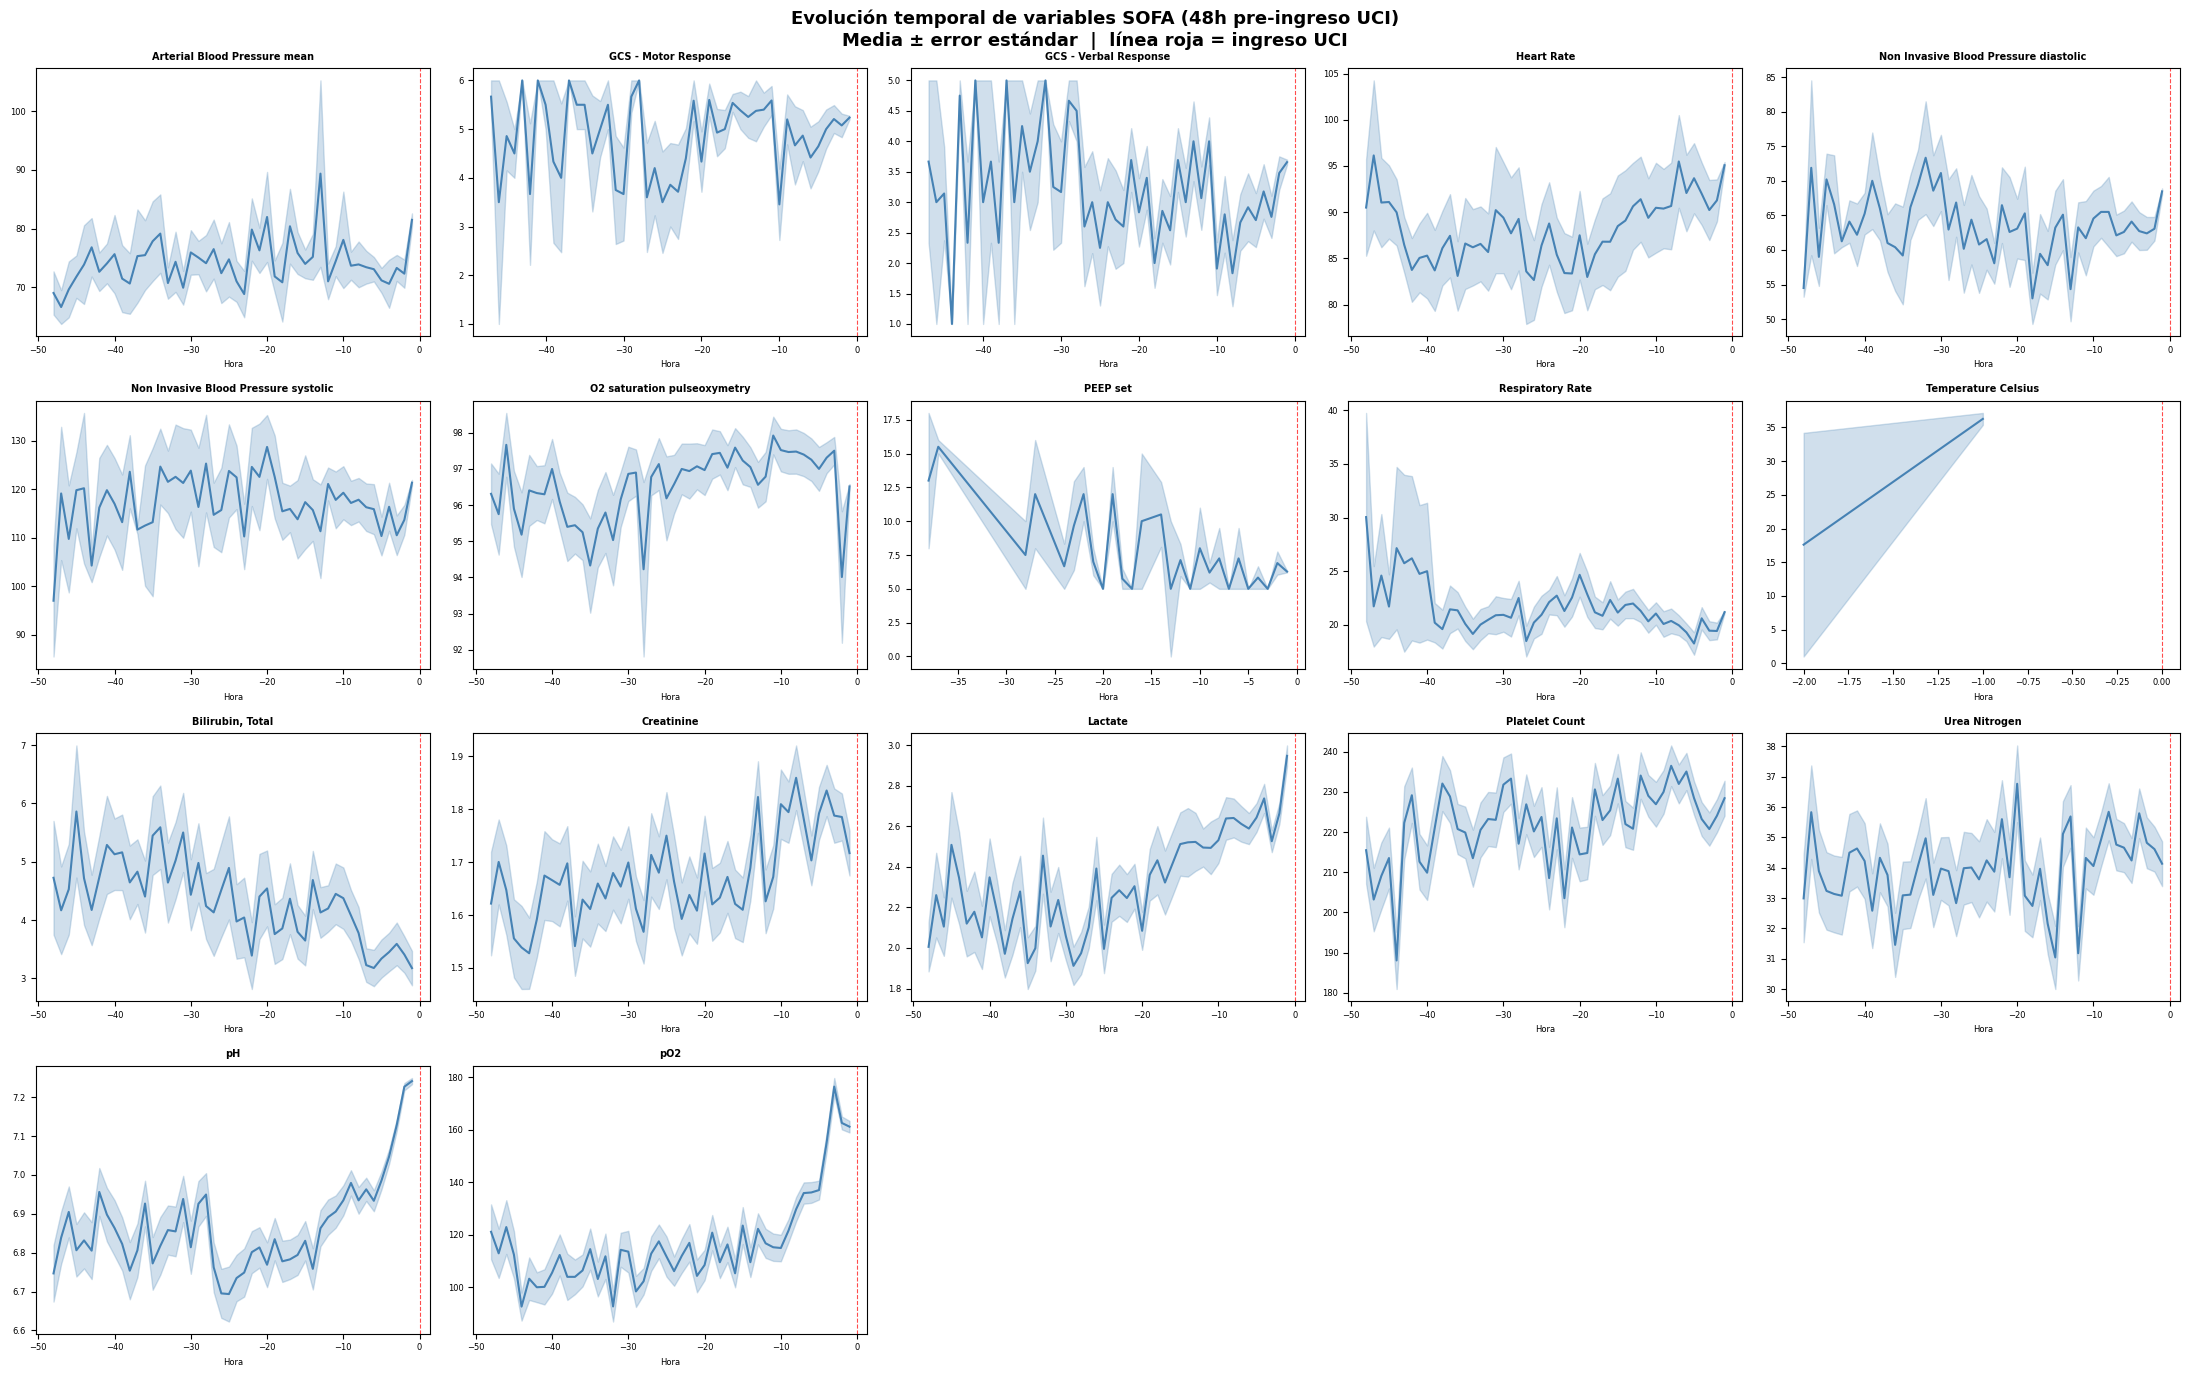

In [23]:
# === Tendencias temporales: media ± error estándar por variable ===
fig, axes = plt.subplots(4, 5, figsize=(22, 14))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    ax = axes[i]
    trend = features_df.groupby('hour_bucket')[col].agg(['mean', 'sem']).dropna()
    if trend.empty:
        ax.set_visible(False)
        continue
    ax.plot(trend.index, trend['mean'], color='steelblue', linewidth=1.5)
    ax.fill_between(
        trend.index,
        trend['mean'] - trend['sem'],
        trend['mean'] + trend['sem'],
        alpha=0.25, color='steelblue'
    )
    ax.axvline(0, color='red', linestyle='--', linewidth=0.8, alpha=0.7, label='Ingreso UCI')
    ax.set_title(col, fontsize=7, fontweight='bold')
    ax.set_xlabel('Hora', fontsize=6)
    ax.tick_params(labelsize=6)

for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle(
    'Evolución temporal de variables SOFA (48h pre-ingreso UCI)\nMedia ± error estándar  |  línea roja = ingreso UCI',
    fontsize=13, fontweight='bold'
)
plt.tight_layout()
plt.show()

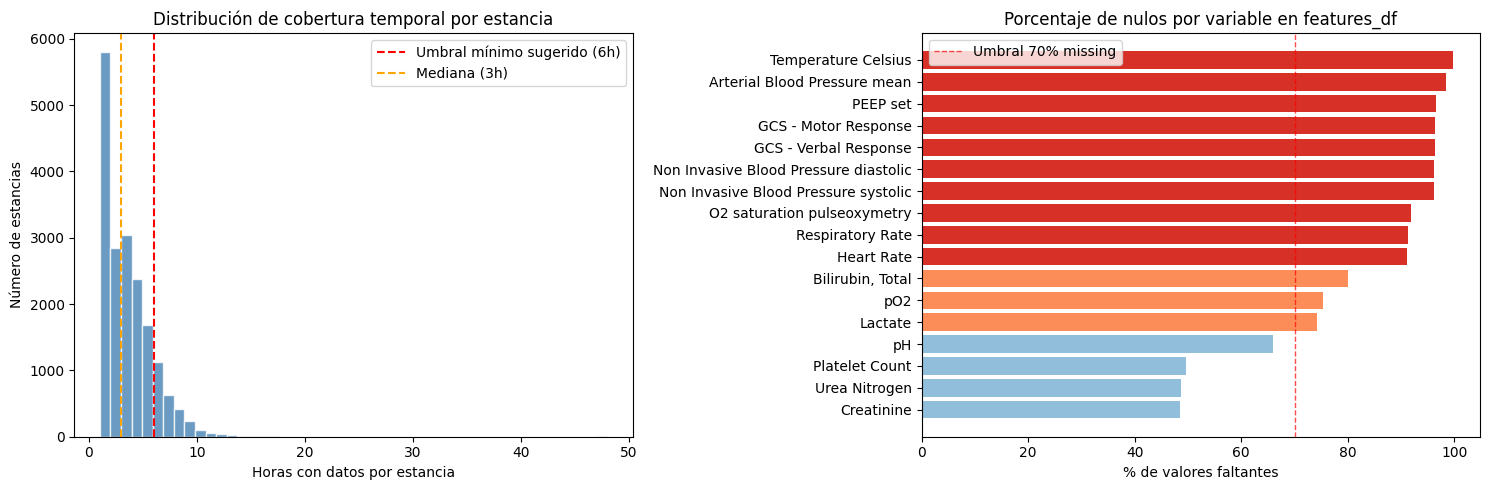


Estancias con >= 6h de datos: 2,706 (14.7%)
Estancias con < 6h de datos:  15,743 (85.3%)


In [24]:
# === Histograma de cobertura temporal por estancia + % nulos por variable ===
horas_por_estancia = features_df.groupby('stay_id')['hour_bucket'].count()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Histograma de horas con datos
ax1.hist(horas_por_estancia, bins=48, color='steelblue', edgecolor='white', alpha=0.8)
ax1.axvline(6, color='red', linestyle='--', linewidth=1.5, label='Umbral mínimo sugerido (6h)')
ax1.axvline(horas_por_estancia.median(), color='orange', linestyle='--', linewidth=1.5,
            label=f'Mediana ({horas_por_estancia.median():.0f}h)')
ax1.set_xlabel('Horas con datos por estancia')
ax1.set_ylabel('Número de estancias')
ax1.set_title('Distribución de cobertura temporal por estancia')
ax1.legend()

# % nulos por variable (barras horizontales)
null_pct_sorted = features_df[feature_cols].isna().mean().sort_values(ascending=True)
colors = ['#d73027' if v > 0.9 else '#fc8d59' if v > 0.7 else '#91bfdb' for v in null_pct_sorted]
ax2.barh(null_pct_sorted.index, null_pct_sorted.values * 100, color=colors)
ax2.axvline(70, color='red', linestyle='--', linewidth=1, alpha=0.7, label='Umbral 70% missing')
ax2.set_xlabel('% de valores faltantes')
ax2.set_title('Porcentaje de nulos por variable en features_df')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nEstancias con >= 6h de datos: {(horas_por_estancia >= 6).sum():,} "
      f"({(horas_por_estancia >= 6).mean()*100:.1f}%)")
print(f"Estancias con < 6h de datos:  {(horas_por_estancia < 6).sum():,} "
      f"({(horas_por_estancia < 6).mean()*100:.1f}%)")

## Exportación

Guardado de la matriz de features final lista para el siguiente paso del pipeline (preprocesado e imputación).

In [26]:
# Exportar matriz de features — entrada para el siguiente notebook
FEATURES_PATH = f'{OUTPUT_DIR}/features_df.parquet'

# pivot_table deja columns.name = 'label', lo que rompe el guardado en parquet
features_df.columns.name = None

features_df.to_parquet(FEATURES_PATH, index=False)
print(f'features_df guardado → {FEATURES_PATH}')
print(f'Shape: {features_df.shape}')
print(f'Variables: {feature_cols}')

features_df guardado → ../data/processed/features_df.parquet
Shape: (59108, 19)
Variables: ['Arterial Blood Pressure mean', 'GCS - Motor Response', 'GCS - Verbal Response', 'Heart Rate', 'Non Invasive Blood Pressure diastolic', 'Non Invasive Blood Pressure systolic', 'O2 saturation pulseoxymetry', 'PEEP set', 'Respiratory Rate', 'Temperature Celsius', 'Bilirubin, Total', 'Creatinine', 'Lactate', 'Platelet Count', 'Urea Nitrogen', 'pH', 'pO2']
